# Segmentasi Citra Glioma

Notebook ini melakukan segmentasi pada semua citra di folder `Glioma` menggunakan tiga metode:

- K-Means Clustering
- Fuzzy C-Means Clustering
- Gaussian Mixture Models

Hasil mask biner disimpan ke `Output/KMeans`, `Output/FCM`, dan `Output/GMM`. File overlay untuk pengecekan visual disimpan ke `Output/Overlay`.

## 1. Import Library

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

from scipy.ndimage import binary_fill_holes, distance_transform_edt
from skimage.color import rgb2gray
from skimage.exposure import equalize_adapthist
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops
from skimage.morphology import (
    binary_closing,
    binary_dilation,
    binary_opening,
    convex_hull_image,
    disk,
    remove_small_holes,
    remove_small_objects,
)
from skimage.segmentation import find_boundaries

warnings.filterwarnings("ignore", category=UserWarning)
%matplotlib inline

## 2. Konfigurasi

Jika hasil segmentasi belum sesuai, parameter yang paling sering perlu disesuaikan adalah `N_CLUSTERS`, `CLUSTER_SELECTION`, `SKULL_STRIP_EROSION_RATIO`, dan batas connected component tumor.

In [2]:
DATA_DIR = Path("Glioma")
OUTPUT_DIR = Path("Output")

MASK_DIRS = {
    "KMeans": OUTPUT_DIR / "KMeans",
    "FCM": OUTPUT_DIR / "FCM",
    "GMM": OUTPUT_DIR / "GMM",
}
OVERLAY_DIR = OUTPUT_DIR / "Overlay"

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}

# Jumlah cluster untuk setiap metode.
N_CLUSTERS = 4

# Strategi pemilihan cluster hasil segmentasi.
# Pilihan: "tumor_like", "brightest", "darkest", "largest", "smallest".
# tumor_like menilai setiap cluster berdasarkan komponen yang compact, terang, dan jauh dari skull/border.
CLUSTER_SELECTION = "tumor_like"

# Fuzzy C-Means.
FCM_M = 2.0
FCM_MAX_ITER = 200
FCM_TOL = 1e-5

# Pra-pemrosesan, skull stripping, dan cleanup mask.
USE_CLAHE = True
USE_SPATIAL_FEATURES = False
SPATIAL_WEIGHT = 0.15

# Radius erosi head mask untuk membuang tengkorak/ring luar.
SKULL_STRIP_EROSION_RATIO = 0.035
SKULL_STRIP_MIN_EROSION = 8
SKULL_STRIP_MAX_EROSION = 18

# Batas komponen tumor kandidat.
MIN_OBJECT_AREA_RATIO = 0.0015
MIN_HOLE_AREA_RATIO = 0.001
MAX_TUMOR_AREA_RATIO = 0.08
MAX_TUMOR_COMPONENTS = 1
MIN_COMPONENT_SOLIDITY = 0.25
MIN_COMPONENT_EXTENT = 0.15
MIN_COMPONENT_INTENSITY_PERCENTILE = 60
KEEP_LARGEST_COMPONENT = False

# Post-processing akhir mask tumor: sambung celah kontur luar lalu isi hole internal.
# Radius 8 membantu kasus seperti Te-gl_62, saat bagian luar hampir tersambung.
FILL_TUMOR_HOLES = True
TUMOR_OUTER_CONNECT_RADIUS = 8

# Refinement global untuk memperluas mask awal pada area tumor terang yang masih terpotong.
# Refinement memakai ROI lokal dari hull mask awal, threshold Otsu citra asli, dan komponen
# yang overlap dengan seed agar tidak bergantung pada nama sampel tertentu.
ENABLE_GLOBAL_REFINEMENT = True
GLOBAL_REFINEMENT_DILATION_RADIUS = 16
GLOBAL_REFINEMENT_THRESHOLD = "otsu"

RANDOM_STATE = 42

for path in [*MASK_DIRS.values(), OVERLAY_DIR]:
    path.mkdir(parents=True, exist_ok=True)

## 3. Fungsi Bantu

In [3]:
def list_images(data_dir: Path) -> list[Path]:
    return sorted(
        path for path in data_dir.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )


def load_rgb_image(path: Path) -> np.ndarray:
    return np.asarray(Image.open(path).convert("RGB"))


def normalize_image(image: np.ndarray) -> np.ndarray:
    image = image.astype(np.float64)
    return (image - image.min()) / (image.max() - image.min() + 1e-12)


def to_gray_image(rgb: np.ndarray) -> np.ndarray:
    return normalize_image(rgb2gray(rgb))


def preprocess_image(gray: np.ndarray) -> np.ndarray:
    processed = normalize_image(gray)
    if USE_CLAHE:
        processed = equalize_adapthist(processed, clip_limit=0.03)
        processed = normalize_image(processed)
    return processed


def keep_largest_region(mask: np.ndarray) -> np.ndarray:
    labeled = label(mask)
    regions = regionprops(labeled)
    if not regions:
        return mask
    largest = max(regions, key=lambda region: region.area)
    return labeled == largest.label


def estimate_brain_mask(gray: np.ndarray) -> np.ndarray:
    # Head mask dibuat dari foreground non-hitam, lalu dierosi berdasarkan distance transform.
    # Erosi ini membuang ring tengkorak dan area luar otak sebelum clustering dilakukan.
    positive_pixels = gray[gray > 0.01]
    if positive_pixels.size == 0:
        return np.ones_like(gray, dtype=bool)

    try:
        otsu_threshold = threshold_otsu(positive_pixels)
    except ValueError:
        otsu_threshold = float(np.percentile(positive_pixels, 10))

    low_threshold = max(0.02, min(float(np.percentile(positive_pixels, 10)), otsu_threshold * 0.45))
    head_mask = gray > low_threshold
    head_mask = binary_closing(head_mask, disk(5))
    head_mask = binary_fill_holes(head_mask)
    head_mask = remove_small_objects(head_mask, min_size=max(64, int(gray.size * 0.02)))
    head_mask = remove_small_holes(head_mask, area_threshold=max(64, int(gray.size * 0.03)))
    head_mask = keep_largest_region(head_mask)

    erosion_radius = int(
        np.clip(
            round(min(gray.shape) * SKULL_STRIP_EROSION_RATIO),
            SKULL_STRIP_MIN_EROSION,
            SKULL_STRIP_MAX_EROSION,
        )
    )
    distance_map = distance_transform_edt(head_mask)
    brain_core = distance_map > erosion_radius
    brain_core = binary_opening(brain_core, disk(2))
    brain_core = binary_closing(brain_core, disk(4))
    brain_core = remove_small_objects(brain_core, min_size=max(64, int(gray.size * 0.02)))
    brain_core = remove_small_holes(brain_core, area_threshold=max(64, int(gray.size * 0.03)))
    brain_core = keep_largest_region(brain_core)

    if brain_core.sum() < max(128, head_mask.sum() * 0.2):
        fallback_radius = max(4, erosion_radius // 2)
        brain_core = keep_largest_region(distance_map > fallback_radius)

    if brain_core.sum() < 32:
        return np.ones_like(gray, dtype=bool)
    return brain_core.astype(bool)


def make_features(gray: np.ndarray, valid_mask: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    rows, cols = np.where(valid_mask)
    intensity = gray[valid_mask].reshape(-1, 1)

    if not USE_SPATIAL_FEATURES:
        return intensity, np.column_stack([rows, cols])

    y = rows / max(1, gray.shape[0] - 1)
    x = cols / max(1, gray.shape[1] - 1)
    spatial = np.column_stack([y, x]) * SPATIAL_WEIGHT
    features = np.column_stack([intensity, spatial])
    return features, np.column_stack([rows, cols])


def select_cluster(labels: np.ndarray, gray_values: np.ndarray, strategy: str) -> int:
    cluster_ids = np.unique(labels)
    stats = []
    for cluster_id in cluster_ids:
        cluster_values = gray_values[labels == cluster_id]
        stats.append({
            "cluster": int(cluster_id),
            "mean_intensity": float(cluster_values.mean()),
            "area": int(cluster_values.size),
        })

    stats_df = pd.DataFrame(stats)
    if strategy == "brightest":
        return int(stats_df.sort_values("mean_intensity", ascending=False).iloc[0]["cluster"])
    if strategy == "darkest":
        return int(stats_df.sort_values("mean_intensity", ascending=True).iloc[0]["cluster"])
    if strategy == "largest":
        return int(stats_df.sort_values("area", ascending=False).iloc[0]["cluster"])
    if strategy == "smallest":
        return int(stats_df.sort_values("area", ascending=True).iloc[0]["cluster"])
    raise ValueError(f"Strategi cluster tidak dikenal: {strategy}")


def labels_to_mask(
    labels: np.ndarray,
    selected_cluster: int,
    coords: np.ndarray,
    shape: tuple[int, int],
) -> np.ndarray:
    mask = np.zeros(shape, dtype=bool)
    selected_coords = coords[labels == selected_cluster]
    mask[selected_coords[:, 0], selected_coords[:, 1]] = True
    return mask


def postprocess_mask(mask: np.ndarray, valid_mask: np.ndarray) -> np.ndarray:
    min_area = max(8, int(mask.size * MIN_OBJECT_AREA_RATIO))
    hole_area = max(8, int(mask.size * MIN_HOLE_AREA_RATIO))
    cleaned = mask & valid_mask
    cleaned = binary_opening(cleaned, disk(1))
    cleaned = binary_closing(cleaned, disk(2))
    cleaned = remove_small_objects(cleaned, min_size=min_area)
    cleaned = remove_small_holes(cleaned, area_threshold=hole_area)
    if KEEP_LARGEST_COMPONENT:
        cleaned = keep_largest_region(cleaned)
    return cleaned.astype(bool)


def finalize_tumor_mask(mask: np.ndarray, valid_mask: np.ndarray) -> np.ndarray:
    min_area = max(8, int(mask.size * MIN_OBJECT_AREA_RATIO))
    cleaned = mask & valid_mask

    if TUMOR_OUTER_CONNECT_RADIUS > 0:
        cleaned = binary_closing(cleaned, disk(TUMOR_OUTER_CONNECT_RADIUS))
        cleaned = cleaned & valid_mask

    if FILL_TUMOR_HOLES:
        cleaned = binary_fill_holes(cleaned)
        cleaned = cleaned & valid_mask

    cleaned = remove_small_objects(cleaned, min_size=min_area)
    if KEEP_LARGEST_COMPONENT:
        cleaned = keep_largest_region(cleaned)
    return cleaned.astype(bool)


def keep_components_overlapping_seed(mask: np.ndarray, seed: np.ndarray) -> np.ndarray:
    labeled = label(mask)
    overlapping_labels = np.unique(labeled[seed])
    overlapping_labels = overlapping_labels[overlapping_labels != 0]

    if overlapping_labels.size == 0:
        regions = regionprops(labeled)
        if not regions:
            return np.zeros_like(mask, dtype=bool)
        largest = max(regions, key=lambda region: region.area)
        return (labeled == largest.label).astype(bool)

    return np.isin(labeled, overlapping_labels).astype(bool)


def resolve_refinement_threshold(values: np.ndarray, threshold: str) -> float:
    if threshold == "otsu":
        try:
            return float(threshold_otsu(values))
        except ValueError:
            return float(np.percentile(values, 60))

    if threshold.startswith("p"):
        return float(np.percentile(values, float(threshold[1:])))

    return float(threshold)


def apply_global_refinement(mask: np.ndarray, raw_gray: np.ndarray) -> np.ndarray:
    if not ENABLE_GLOBAL_REFINEMENT or mask.sum() == 0:
        return mask.astype(bool)

    seed_hull = convex_hull_image(mask)
    roi = binary_dilation(seed_hull, disk(GLOBAL_REFINEMENT_DILATION_RADIUS))
    if not roi.any():
        return mask.astype(bool)

    threshold = resolve_refinement_threshold(raw_gray[roi], GLOBAL_REFINEMENT_THRESHOLD)
    refined = (raw_gray >= threshold) & roi
    refined = keep_components_overlapping_seed(refined, mask)
    refined = binary_closing(refined, disk(2))
    refined = binary_fill_holes(refined)
    refined = remove_small_objects(
        refined,
        min_size=max(20, int(mask.size * MIN_OBJECT_AREA_RATIO)),
    )

    if refined.sum() == 0:
        return mask.astype(bool)
    return refined.astype(bool)


def score_and_select_tumor_components(
    mask: np.ndarray,
    raw_gray: np.ndarray,
    valid_mask: np.ndarray,
) -> tuple[np.ndarray, float]:
    labeled = label(mask)
    regions = regionprops(labeled, intensity_image=raw_gray)
    if not regions:
        return np.zeros_like(mask, dtype=bool), -np.inf

    valid_intensities = raw_gray[valid_mask]
    min_area = max(20, int(mask.size * MIN_OBJECT_AREA_RATIO))
    max_area = max(min_area + 1, int(valid_mask.sum() * MAX_TUMOR_AREA_RATIO))
    p_min = np.percentile(valid_intensities, MIN_COMPONENT_INTENSITY_PERCENTILE)
    p_high = np.percentile(valid_intensities, 95)
    distance_map = distance_transform_edt(valid_mask)
    max_distance = distance_map.max() + 1e-12

    scored_regions = []
    for region in regions:
        area = region.area
        bbox_area = (region.bbox[2] - region.bbox[0]) * (region.bbox[3] - region.bbox[1])
        extent = area / (bbox_area + 1e-12)
        solidity = region.solidity
        mean_intensity = float(region.mean_intensity)

        if area < min_area or area > max_area:
            continue
        if extent < MIN_COMPONENT_EXTENT or solidity < MIN_COMPONENT_SOLIDITY:
            continue
        if mean_intensity < p_min:
            continue

        coords = tuple(region.coords.T)
        distance_score = float(distance_map[coords].mean() / max_distance)
        area_score = min(area / (valid_mask.sum() * 0.025 + 1e-12), 1.0)
        intensity_score = (mean_intensity - p_min) / (p_high - p_min + 1e-12)
        compact_score = 0.55 * solidity + 0.45 * extent
        eccentricity_penalty = max(0.0, region.eccentricity - 0.92) * 2.0
        score = (
            2.5 * intensity_score
            + 1.4 * compact_score
            + 0.8 * area_score
            + 0.6 * distance_score
            - eccentricity_penalty
        )
        scored_regions.append((score, region.label))

    if not scored_regions:
        # Fallback lebih longgar agar notebook tetap menghasilkan mask saat karakter tumor berbeda.
        for region in regions:
            area = region.area
            if area < min_area or area > max_area:
                continue
            bbox_area = (region.bbox[2] - region.bbox[0]) * (region.bbox[3] - region.bbox[1])
            extent = area / (bbox_area + 1e-12)
            score = float(region.mean_intensity) + 0.4 * region.solidity + 0.2 * extent
            scored_regions.append((score, region.label))

    if not scored_regions:
        return np.zeros_like(mask, dtype=bool), -np.inf

    selected_labels = [
        region_label
        for _, region_label in sorted(scored_regions, reverse=True)[:MAX_TUMOR_COMPONENTS]
    ]
    selected_mask = np.isin(labeled, selected_labels)
    selected_mask = binary_closing(selected_mask, disk(2))
    selected_mask = remove_small_holes(
        selected_mask,
        area_threshold=max(8, int(mask.size * MIN_HOLE_AREA_RATIO)),
    )
    return selected_mask.astype(bool), float(max(score for score, _ in scored_regions))


def build_tumor_like_mask(
    labels: np.ndarray,
    coords: np.ndarray,
    shape: tuple[int, int],
    raw_gray: np.ndarray,
    valid_mask: np.ndarray,
) -> np.ndarray:
    best_mask = np.zeros(shape, dtype=bool)
    best_score = -np.inf

    for cluster_id in np.unique(labels):
        raw_cluster_mask = labels_to_mask(labels, int(cluster_id), coords, shape)
        cleaned_cluster_mask = postprocess_mask(raw_cluster_mask, valid_mask)
        candidate_mask, candidate_score = score_and_select_tumor_components(
            cleaned_cluster_mask,
            raw_gray,
            valid_mask,
        )
        if candidate_score > best_score and candidate_mask.sum() > 0:
            best_score = candidate_score
            best_mask = candidate_mask

    return best_mask.astype(bool)


def save_binary_mask(mask: np.ndarray, output_path: Path) -> None:
    Image.fromarray((mask.astype(np.uint8) * 255)).save(output_path)


def create_overlay(rgb: np.ndarray, mask: np.ndarray, alpha: float = 0.45) -> np.ndarray:
    overlay = rgb.astype(np.float64).copy()
    color = np.array([255, 0, 0], dtype=np.float64)
    overlay[mask] = (1 - alpha) * overlay[mask] + alpha * color
    boundaries = find_boundaries(mask, mode="outer")
    overlay[boundaries] = np.array([255, 255, 0], dtype=np.float64)
    return np.clip(overlay, 0, 255).astype(np.uint8)

## 4. Implementasi Metode Segmentasi

In [4]:
def run_kmeans(features: np.ndarray, n_clusters: int) -> np.ndarray:
    model = KMeans(
        n_clusters=n_clusters,
        n_init=10,
        random_state=RANDOM_STATE,
    )
    return model.fit_predict(features)


def run_fuzzy_c_means(
    features: np.ndarray,
    n_clusters: int,
    m: float = FCM_M,
    max_iter: int = FCM_MAX_ITER,
    tol: float = FCM_TOL,
) -> np.ndarray:
    if m <= 1:
        raise ValueError("Parameter fuzziness m harus lebih besar dari 1.")

    rng = np.random.default_rng(RANDOM_STATE)
    n_samples = features.shape[0]
    membership = rng.random((n_samples, n_clusters))
    membership = membership / membership.sum(axis=1, keepdims=True)

    for _ in range(max_iter):
        previous_membership = membership.copy()
        membership_m = membership ** m
        centers = (membership_m.T @ features) / (membership_m.sum(axis=0)[:, None] + 1e-12)

        distances = np.linalg.norm(features[:, None, :] - centers[None, :, :], axis=2)
        distances = np.maximum(distances, np.finfo(np.float64).eps)
        inv_distances = distances ** (-2.0 / (m - 1.0))
        membership = inv_distances / inv_distances.sum(axis=1, keepdims=True)

        if np.linalg.norm(membership - previous_membership) < tol:
            break

    return membership.argmax(axis=1)


def run_gmm(features: np.ndarray, n_clusters: int) -> np.ndarray:
    model = GaussianMixture(
        n_components=n_clusters,
        covariance_type="full",
        n_init=3,
        random_state=RANDOM_STATE,
    )
    return model.fit_predict(features)


def segment_single_image(image_path: Path) -> dict[str, np.ndarray]:
    rgb = load_rgb_image(image_path)
    raw_gray = to_gray_image(rgb)
    gray = preprocess_image(raw_gray)
    valid_mask = estimate_brain_mask(raw_gray)
    features, coords = make_features(gray, valid_mask)
    gray_values = gray[valid_mask]

    if features.shape[0] < 2:
        empty = np.zeros(gray.shape, dtype=bool)
        return {"KMeans": empty, "FCM": empty, "GMM": empty}

    n_clusters = min(N_CLUSTERS, features.shape[0])
    method_labels = {
        "KMeans": run_kmeans(features, n_clusters),
        "FCM": run_fuzzy_c_means(features, n_clusters),
        "GMM": run_gmm(features, n_clusters),
    }

    masks = {}
    for method_name, labels in method_labels.items():
        if CLUSTER_SELECTION == "tumor_like":
            mask = build_tumor_like_mask(
                labels,
                coords,
                gray.shape,
                raw_gray,
                valid_mask,
            )
        else:
            selected_cluster = select_cluster(labels, gray_values, CLUSTER_SELECTION)
            raw_mask = labels_to_mask(labels, selected_cluster, coords, gray.shape)
            mask = postprocess_mask(raw_mask, valid_mask)

        final_mask = finalize_tumor_mask(mask, valid_mask)
        final_mask = apply_global_refinement(final_mask, raw_gray)
        masks[method_name] = final_mask

    return masks

## 5. Jalankan Segmentasi untuk Semua Citra

In [5]:
image_paths = list_images(DATA_DIR)
if not image_paths:
    raise FileNotFoundError(f"Tidak ada file citra di folder: {DATA_DIR.resolve()}")

records = []

for image_path in image_paths:
    rgb = load_rgb_image(image_path)
    masks = segment_single_image(image_path)

    for method_name, mask in masks.items():
        mask_path = MASK_DIRS[method_name] / f"{image_path.stem}.png"
        overlay_path = OVERLAY_DIR / f"{image_path.stem}_{method_name}_overlay.png"

        save_binary_mask(mask, mask_path)
        Image.fromarray(create_overlay(rgb, mask)).save(overlay_path)

        records.append({
            "Image": image_path.name,
            "Method": method_name,
            "Mask Path": str(mask_path),
            "Overlay Path": str(overlay_path),
            "Foreground Pixels": int(mask.sum()),
            "Foreground Ratio": float(mask.mean()),
        })

segmentasi_df = pd.DataFrame(records)
segmentasi_df

,Image,Method,Mask Path,Overlay Path,Foreground Pixels,Foreground Ratio
0,Te-gl_106.jpg,KMeans,Output\KMeans\Te-gl_106.png,Output\Overlay\Te-gl_106_KMeans_overlay.png,2458,0.044132
1,Te-gl_106.jpg,FCM,Output\FCM\Te-gl_106.png,Output\Overlay\Te-gl_106_FCM_overlay.png,2458,0.044132
2,Te-gl_106.jpg,GMM,Output\GMM\Te-gl_106.png,Output\Overlay\Te-gl_106_GMM_overlay.png,2458,0.044132
3,Te-gl_115.jpg,KMeans,Output\KMeans\Te-gl_115.png,Output\Overlay\Te-gl_115_KMeans_overlay.png,2206,0.015880
4,Te-gl_115.jpg,FCM,Output\FCM\Te-gl_115.png,Output\Overlay\Te-gl_115_FCM_overlay.png,2206,0.015880
5,Te-gl_115.jpg,GMM,Output\GMM\Te-gl_115.png,Output\Overlay\Te-gl_115_GMM_overlay.png,2213,0.015930
6,Te-gl_14.jpg,KMeans,Output\KMeans\Te-gl_14.png,Output\Overlay\Te-gl_14_KMeans_overlay.png,2927,0.011166
7,Te-gl_14.jpg,FCM,Output\FCM\Te-gl_14.png,Output\Overlay\Te-gl_14_FCM_overlay.png,2927,0.011166
8,Te-gl_14.jpg,GMM,Output\GMM\Te-gl_14.png,Output\Overlay\Te-gl_14_GMM_overlay.png,2927,0.011166
9,Te-gl_218.jpg,KMeans,Output\KMeans\Te-gl_218.png,Output\Overlay\Te-gl_218_KMeans_overlay.png,4735,0.018063


## 6. Preview Hasil Segmentasi

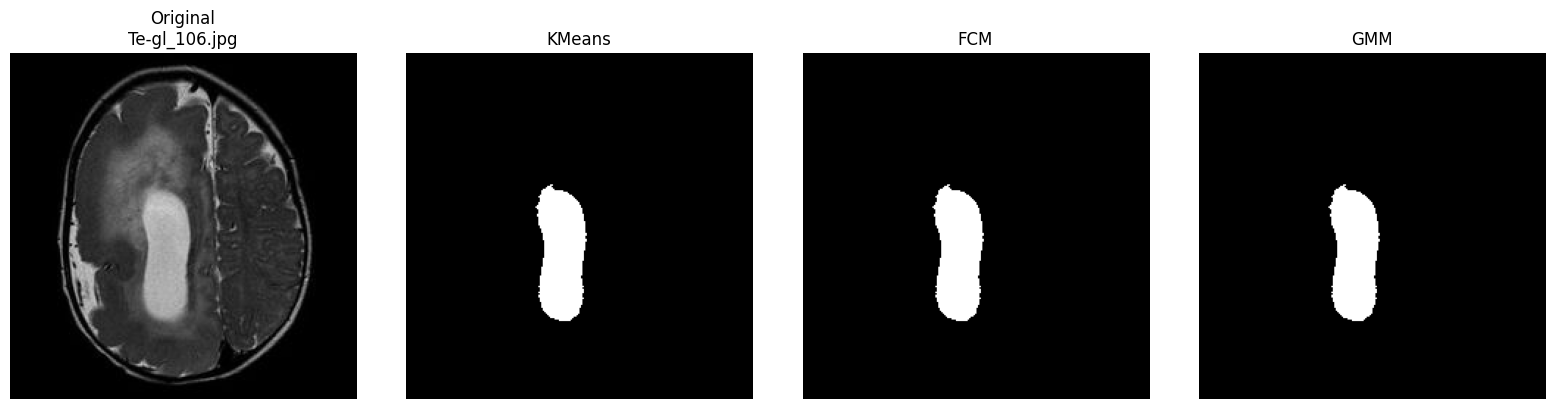

In [6]:
sample_path = image_paths[0]
sample_rgb = load_rgb_image(sample_path)
sample_masks = {method: np.asarray(Image.open(MASK_DIRS[method] / f"{sample_path.stem}.png").convert("L")) > 127 for method in MASK_DIRS}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(sample_rgb)
axes[0].set_title(f"Original\n{sample_path.name}")
axes[0].axis("off")

for ax, (method_name, mask) in zip(axes[1:], sample_masks.items()):
    ax.imshow(mask, cmap="gray")
    ax.set_title(method_name)
    ax.axis("off")

plt.tight_layout()
plt.show()